# Install packages

In [ ]:
# %pip install statsmodels
# %pip install openpyxl
# %pip install streamlit
# %pip install pydantic

  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.3 MB/s  0:00:00 eta 0:00:01
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pydantic]3/4 [pydantic]
Note: you may need to restart the kernel to use updated packages.


# 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import os

os.environ.pop("GOOGLE_APPLICATION_CREDENTIALS", None)

from google.cloud import bigquery

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

# 2. Loading Data

## 2.1 Connection to Bigquery

Note that we've created tables intermediary tables in Bigquery that have our features, target variable and data quality. We'll connect to our Bigquery project then pull the relevant tables into dataframes

In [3]:
PROJECT_ID = "credit-risk-modelling-499009"

client = bigquery.Client(project=PROJECT_ID)

Pulling features from Bigquery

In [4]:
features_sql = """ SELECT * FROM credit-risk-modelling-499009.staging_intermediate.intermediate_credit_risk_features """ 
features_df = client.query(features_sql).to_dataframe()

In [5]:
features_df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate_pct,installment,grade,sub_grade,purpose,application_type,emp_length_years,annual_inc,home_ownership,dti,fico_score,last_fico_score,delinq_2yrs,acc_now_delinq,inq_last_6mths,inq_last_12m,open_acc,total_acc,mort_acc,pub_rec,revol_bal,revol_util_pct,total_rev_hi_lim,tot_cur_bal,total_bc_limit,bc_util,all_util,issue_date,earliest_credit_line_date,credit_history_months,loan_to_income_ratio,installment_income_ratio,funded_to_income_ratio,fico_change,delinquency_flag,recent_inquiry_flag,high_utilization_flag,thin_file_flag,mortgage_flag,employment_stability_flag,fico_band,high_dti_flag,revolving_balance_ratio,balance_to_limit_ratio,subprime_flag
0,38842175,13700.0,13700.0,13700.0,7.490000000,426.10,A,A4,debt_consolidation,Individual,10,62000.0,MORTGAGE,19.05,762.0,752.0,0.0,0.0,0.0,NaN,11.0,20.0,6.0,0.0,8495.0,16.700000000,51000.0,239315.0,48000.0,16.9,NaN,2015-01-01,2003-05-01,140,0.220968,0.006873,0.220968,-10.0,0,0,0,0,1,1,Very Good,0,0.166569,4.985729,0
1,125224968,14000.0,14000.0,14000.0,10.420000000,300.37,B,B3,debt_consolidation,Joint App,7,60000.0,OWN,34.12,737.0,742.0,1.0,0.0,0.0,3.0,16.0,38.0,3.0,0.0,35120.0,53.100000000,66100.0,104919.0,60600.0,52.3,63.0,2017-12-01,1985-09-01,387,0.233333,0.005006,0.233333,5.0,1,0,0,0,1,1,Good,0,0.531316,1.731337,0
2,129363122,14000.0,14000.0,14000.0,15.040000000,333.36,C,C4,major_purchase,Individual,0,55000.0,OWN,31.29,727.0,672.0,0.0,0.0,1.0,6.0,7.0,9.0,0.0,0.0,6364.0,28.700000000,22200.0,66166.0,15200.0,41.9,60.0,2018-03-01,2009-08-01,103,0.254545,0.006061,0.254545,-55.0,0,1,0,0,0,0,Good,0,0.286667,4.353026,0
3,1334499,14000.0,14000.0,14000.0,9.760000000,450.17,B,B1,debt_consolidation,Individual,0,70366.0,RENT,18.12,712.0,692.0,0.0,0.0,0.0,NaN,11.0,19.0,0.0,0.0,31422.0,50.800000000,NaN,NaN,43849.0,71.4,NaN,2012-06-01,1986-05-01,313,0.198960,0.006398,0.198960,-20.0,0,0,0,0,0,0,Good,0,NaN,NaN,0
4,117232705,14400.0,14400.0,14400.0,10.910000000,470.83,B,B4,credit_card,Individual,10,74000.0,MORTGAGE,13.17,722.0,672.0,0.0,0.0,0.0,1.0,9.0,21.0,1.0,0.0,19555.0,52.600000000,37200.0,187521.0,32200.0,60.7,58.0,2017-08-01,1993-05-01,291,0.194595,0.006363,0.194595,-50.0,0,0,0,0,1,1,Good,0,0.525672,5.823634,0


Pulling our target feature from Bigquery

In [6]:
target_sql = """
SELECT *
FROM `credit-risk-modelling-499009.staging_intermediate.intermediate_default_target`
"""

target_df = client.query(target_sql).to_dataframe()

In [7]:
target_df.head()

,id,loan_status,default_flag
0,120654047,Current,0
1,130395508,Current,0
2,128210844,Current,0
3,145167263,Current,0
4,141637736,Current,0


Pulling quality table from Bigquery

In [8]:
quality_sql = """
SELECT *
FROM `credit-risk-modelling-499009.staging_intermediate.intermediate_feature_quality`
"""

quality_df = client.query(quality_sql).to_dataframe()

In [9]:
quality_df.head()

,total_records,missing_annual_income,missing_fico_score,missing_revol_utilization,missing_dti,missing_credit_history,missing_loan_income_ratio,missing_fico_change,avg_fico_score,avg_annual_income,avg_revol_utilization,avg_dti
0,2925492,4,0,2660,3108,29,3058,0,702.511133,79937.274015,48.986439375,19.29648


Joining features from Bigquery and target feature

In [10]:
df = features_df.merge(
    target_df[["id","default_flag"]],
    on="id",
    how="inner"
)

In [11]:
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate_pct,installment,grade,sub_grade,purpose,application_type,emp_length_years,annual_inc,home_ownership,dti,fico_score,last_fico_score,delinq_2yrs,acc_now_delinq,inq_last_6mths,inq_last_12m,open_acc,total_acc,mort_acc,pub_rec,revol_bal,revol_util_pct,total_rev_hi_lim,tot_cur_bal,total_bc_limit,bc_util,all_util,issue_date,earliest_credit_line_date,credit_history_months,loan_to_income_ratio,installment_income_ratio,funded_to_income_ratio,fico_change,delinquency_flag,recent_inquiry_flag,high_utilization_flag,thin_file_flag,mortgage_flag,employment_stability_flag,fico_band,high_dti_flag,revolving_balance_ratio,balance_to_limit_ratio,subprime_flag,default_flag
0,38842175,13700.0,13700.0,13700.0,7.490000000,426.10,A,A4,debt_consolidation,Individual,10,62000.0,MORTGAGE,19.05,762.0,752.0,0.0,0.0,0.0,NaN,11.0,20.0,6.0,0.0,8495.0,16.700000000,51000.0,239315.0,48000.0,16.9,NaN,2015-01-01,2003-05-01,140,0.220968,0.006873,0.220968,-10.0,0,0,0,0,1,1,Very Good,0,0.166569,4.985729,0,0
1,125224968,14000.0,14000.0,14000.0,10.420000000,300.37,B,B3,debt_consolidation,Joint App,7,60000.0,OWN,34.12,737.0,742.0,1.0,0.0,0.0,3.0,16.0,38.0,3.0,0.0,35120.0,53.100000000,66100.0,104919.0,60600.0,52.3,63.0,2017-12-01,1985-09-01,387,0.233333,0.005006,0.233333,5.0,1,0,0,0,1,1,Good,0,0.531316,1.731337,0,0
2,129363122,14000.0,14000.0,14000.0,15.040000000,333.36,C,C4,major_purchase,Individual,0,55000.0,OWN,31.29,727.0,672.0,0.0,0.0,1.0,6.0,7.0,9.0,0.0,0.0,6364.0,28.700000000,22200.0,66166.0,15200.0,41.9,60.0,2018-03-01,2009-08-01,103,0.254545,0.006061,0.254545,-55.0,0,1,0,0,0,0,Good,0,0.286667,4.353026,0,0
3,1334499,14000.0,14000.0,14000.0,9.760000000,450.17,B,B1,debt_consolidation,Individual,0,70366.0,RENT,18.12,712.0,692.0,0.0,0.0,0.0,NaN,11.0,19.0,0.0,0.0,31422.0,50.800000000,NaN,NaN,43849.0,71.4,NaN,2012-06-01,1986-05-01,313,0.198960,0.006398,0.198960,-20.0,0,0,0,0,0,0,Good,0,NaN,NaN,0,0
4,117232705,14400.0,14400.0,14400.0,10.910000000,470.83,B,B4,credit_card,Individual,10,74000.0,MORTGAGE,13.17,722.0,672.0,0.0,0.0,0.0,1.0,9.0,21.0,1.0,0.0,19555.0,52.600000000,37200.0,187521.0,32200.0,60.7,58.0,2017-08-01,1993-05-01,291,0.194595,0.006363,0.194595,-50.0,0,0,0,0,1,1,Good,0,0.525672,5.823634,0,0


# 3. Dataset Overview

## 3.1 Dataset shape

Let's see how many rows and columns we have in our full dataset

In [12]:
print(df.shape)

(2925492, 50)


## 3.2 Data inspection

Below, we'll see data types for our features and we need to make sure our target variable is an integer and not a string

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 50 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   id                         object 
 1   loan_amnt                  float64
 2   funded_amnt                float64
 3   funded_amnt_inv            float64
 4   int_rate_pct               object 
 5   installment                float64
 6   grade                      object 
 7   sub_grade                  object 
 8   purpose                    object 
 9   application_type           object 
 10  emp_length_years           Int64  
 11  annual_inc                 float64
 12  home_ownership             object 
 13  dti                        float64
 14  fico_score                 float64
 15  last_fico_score            float64
 16  delinq_2yrs                float64
 17  acc_now_delinq             float64
 18  inq_last_6mths             float64
 19  inq_last_12m               float64
 20  op

# 4. Data Preprocessing & Feature Engineering

## Train / Validation / Test Split
To ensure robust model evaluation and prevent data leakage, we will split our raw data into three distinct sets:

- Training Set (70%): Used to calculate imputation means, fit optimal bins (WoE), and train the Logistic Regression model.

- Validation Set (15%): Used for hyperparameter tuning and early stopping (if using gradient boosting).

- Test Set (15%): A strict hold-out set used only for final performance evaluation.

**Best Practice Note on Data Leakage**: We perform this split before any preprocessing. If we imputed missing values using the mean of the entire dataset before splitting, information from the test set would "leak" into the training set, artificially inflating our model's performance.

In [14]:
from sklearn.model_selection import train_test_split

# Drop redundant raw date columns before splitting
df = df.drop(columns=["earliest_credit_line_date"])

# TODO: Update this to match your actual target column name from EDA
target_col = "default_flag" 

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# STEP 1: Split off the Training Set (70%) and a Temporary Set (30%)
# We use stratify=y to ensure the default rate remains identical across splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, 
    random_state=42
)

# STEP 2: Split the Temporary Set in half to create Validation (15%) and Test (15%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)

# Verify the splits
print("Data Split Summary:")
print("-" * 30)
print(f"Total rows:      {len(df):,}")
print(f"Training Set:    {len(X_train):,} ({len(X_train)/len(df):.0%})")
print(f"Validation Set:  {len(X_valid):,} ({len(X_valid)/len(df):.0%})")
print(f"Test Set:        {len(X_test):,} ({len(X_test)/len(df):.0%})")

print("\nDefault Rates:")
print("-" * 30)
print(f"Population:      {y.mean():.4f}")
print(f"Training Set:    {y_train.mean():.4f}")
print(f"Validation Set:  {y_valid.mean():.4f}")
print(f"Test Set:        {y_test.mean():.4f}")

Data Split Summary:
------------------------------
Total rows:      2,925,492
Training Set:    2,047,844 (70%)
Validation Set:  438,824 (15%)
Test Set:        438,824 (15%)

Default Rates:
------------------------------
Population:      0.1299
Training Set:    0.1299
Validation Set:  0.1299
Test Set:        0.1299


With our EDA complete, we will now push our raw data through the custom PreprocessingPipeline. This pipeline guarantees consistency between our training and testing sets while executing the following steps sequentially:

- Imputation: Grouped mean imputation for numericals; explicit  "Missing" category for categoricals.

- Binning & WoE: Optimal binning to maximize Information Value (IV) and transformation into Weight of Evidence.

- Information Value (IV) Selection: Dropping weak predictors.

- Correlation Filtering: Removing highly correlated features (keeping the one with the highest IV).

- Variance Inflation Factor (VIF): Removing residual multicollinearity to ensure stable logistic regression coefficients.

In [15]:
# Import custom preprocessing modules
from preprocessing.preprocessing_pipeline import PreprocessingConfig, PreprocessingPipeline

# 1. Map these to the actual dataset columns identified during your EDA
numerical_group_mapping = {
    "annual_inc": "grade",
    "dti": "grade",
    "funded_to_income_ratio": "grade",
    "loan_to_income_ratio": "grade",
    "installment_income_ratio": "grade",
    "emp_length_years": "grade",
    
    # ---------------------------------------------------------
    # Utilization Metrics -> 'fico_band'
    # ---------------------------------------------------------
    "all_util": "fico_band",
    "bc_util": "fico_band",
    "revol_util_pct": "fico_band",
    "balance_to_limit_ratio": "fico_band",
    "revolving_balance_ratio": "fico_band",
    
    # ---------------------------------------------------------
    # Credit Limits & Balances -> 'grade'
    # ---------------------------------------------------------
    "tot_cur_bal": "grade",
    "total_rev_hi_lim": "grade",
    "total_bc_limit": "grade",
    "total_acc": "grade",
    "open_acc": "grade",
    
    # ---------------------------------------------------------
    # Credit History & Derogatory Marks -> 'fico_band'
    # ---------------------------------------------------------
    "inq_last_12m": "fico_band",
    "inq_last_6mths": "fico_band",
    "acc_now_delinq": "fico_band",
    "delinq_2yrs": "fico_band",
    "pub_rec": "fico_band",
    "credit_history_months": "fico_band",
    "mort_acc": "home_ownership",
}

categorical_cols = []

# 2. Initialize configuration with our required mappings and thresholds
prep_config = PreprocessingConfig(
    feature_group_map=numerical_group_mapping,
    categorical_features=categorical_cols,
    iv_min=0.02,
    iv_max=0.50,          # Cap to prevent target leakage
    corr_threshold=0.70,
    vif_threshold=5.0
)

# 3. Instantiate the orchestrator
pipeline = PreprocessingPipeline(config=prep_config)

# 4. Fit and transform the TRAINING data
print("Fitting preprocessing pipeline on training data (this may take a moment)...")
X_train_prep = pipeline.fit_transform(X_train, y_train)

# 5. Safely transform VALIDATION and TEST data
print("Transforming validation and test data...")
X_valid_prep = pipeline.transform(X_valid)
X_test_prep = pipeline.transform(X_test)

# Review the final selected features
print("\nPipeline Summary (Surviving Features):")
display(pipeline.summary())

Fitting preprocessing pipeline on training data (this may take a moment)...
Transforming validation and test data...

Pipeline Summary (Surviving Features):


,Final Features
0,fico_score
1,inq_last_12m
2,all_util
3,installment_income_ratio
4,total_bc_limit
5,inq_last_6mths
6,bc_util
7,tot_cur_bal
8,annual_inc
9,home_ownership


In [16]:
X_train_prep.head()

,fico_score,inq_last_12m,all_util,installment_income_ratio,total_bc_limit,inq_last_6mths,bc_util,tot_cur_bal,annual_inc,home_ownership,installment,dti
2886337,-0.046960,0.487609,-0.019744,-0.351896,-0.131054,0.170212,0.330253,-0.143014,-0.196255,-0.175482,0.158364,0.019055
489096,0.484465,-0.364398,-0.233175,0.162661,0.235259,-0.441379,0.087279,0.312277,0.023939,0.162789,-0.083386,-0.196492
625791,0.925119,0.487609,0.305521,-0.148167,0.235259,0.170212,0.330253,-0.143014,-0.196255,-0.175482,-0.083386,-0.196492
1523383,-0.046960,0.326501,-0.019744,0.339732,0.235259,0.170212,-0.147867,-0.059475,0.261338,-0.014692,0.020220,-0.196492
1564602,0.202673,-0.364398,-0.233175,0.339732,0.235259,-0.441379,-0.067073,0.129764,-0.196255,-0.175482,0.378173,-0.091548


In [17]:
# 1. Overall IV Summary for all features
print("Overall Information Value (IV) Summary:")
iv_summary = pipeline.woe_.summary()
display(iv_summary)

Overall Information Value (IV) Summary:


,Feature,Type,IV,Status
0,last_fico_score,numerical,4.039730,OPTIMAL
1,fico_change,numerical,3.717314,OPTIMAL
2,int_rate_pct,categorical,0.812188,OPTIMAL
3,sub_grade,categorical,0.530569,OPTIMAL
4,grade,categorical,0.517340,OPTIMAL
5,issue_date,categorical,0.509099,OPTIMAL
6,fico_score,numerical,0.149549,OPTIMAL
7,inq_last_12m,numerical,0.130247,OPTIMAL
8,all_util,numerical,0.107044,OPTIMAL
9,fico_band,categorical,0.104903,OPTIMAL


In [18]:
# 2. Detailed binning table for a single feature
feature_to_inspect = "annual_inc"  # Change this to any feature name in your dataset

print(f"\nDetailed Binning Table for '{feature_to_inspect}':")
bin_table = pipeline.woe_.get_binning_table(feature_to_inspect)
display(bin_table)


Detailed Binning Table for 'annual_inc':


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 49908.02)",559200,0.273068,473258,85942,0.153687,-0.196255,0.011302,0.001411
1,"[49908.02, 65099.50)",455966,0.222657,392309,63657,0.139609,-0.083683,0.001608,0.000201
2,"[65099.50, 85850.50)",396427,0.193583,346011,50416,0.127176,0.023939,0.000110,0.000014
3,"[85850.50, 102637.50)",219218,0.107048,193945,25273,0.115287,0.135615,0.001872,0.000234
4,"[102637.50, 150342.50)",282961,0.138175,253796,29165,0.103071,0.261338,0.008560,0.001067
5,"[150342.50, inf)",134072,0.065470,122598,11474,0.085581,0.466604,0.011970,0.001483
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,2047844,1.000000,1781917,265927,0.129857,,0.035423,0.004409



WoE Plot for 'annual_inc':


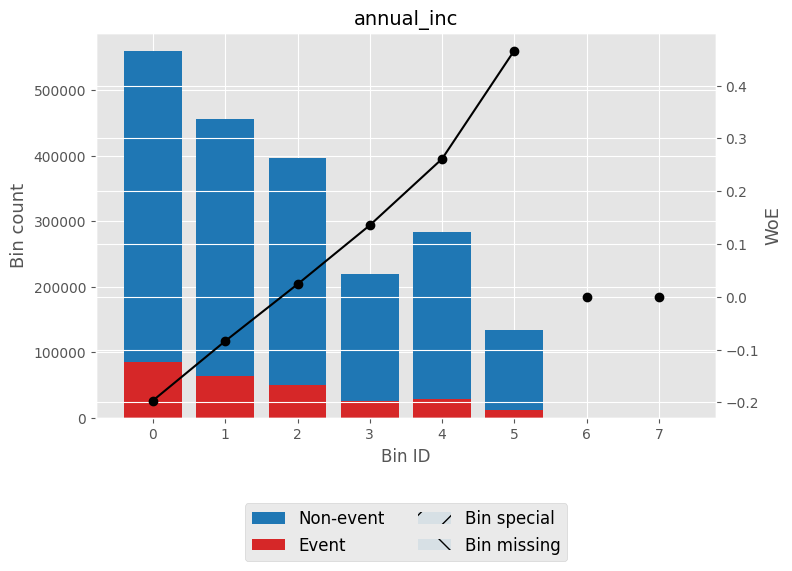

In [19]:
# 3. Plot the Weight of Evidence (WoE) across bins
print(f"\nWoE Plot for '{feature_to_inspect}':")
pipeline.woe_.plot(feature_to_inspect, metric="woe")

# Alternatively, you can plot the raw event (default) rate instead of WoE:
# pipeline.woe_.plot(feature_to_inspect, metric="event_rate")

# 5. Model Building (Logistic Regression)
For credit scorecards, Logistic Regression is the industry standard due to its transparency, interpretability, and linear additive nature (which allows us to map coefficients directly to scorecard points).

We will train our custom LogisticRegressionModel on the perfectly uncorrelated, WoE-transformed dataset.

In [33]:
from modeling.logistic_model import LogisticRegressionConfig, LogisticRegressionModel

# 1. Initialize Configuration
log_config = LogisticRegressionConfig(
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced", 
    random_state=42
)

# 2. Instantiate Model
lr_model = LogisticRegressionModel(config=log_config)

# 3. Hyperparameter Tuning using the Validation Set
print("Tuning Logistic Regression hyperparameters...")
param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0]
}
tune_results = lr_model.tune(X_train_prep, y_train, param_grid=param_grid)

# 4. Fit final model to populate all metadata and state attributes
print("Fitting final tuned model...")
lr_model.fit(X_train_prep, y_train)

# 5. Check Feature Importance (Absolute Coefficients & Odds Ratios)
print("\nFeature Importances:")
display(lr_model.get_feature_importance())

# 6. Save the Logistic Regression artifacts to the project root's outputs folder
lr_model.save("../outputs/logistic_model.pkl")
print("Champion Logistic Regression model successfully saved to the project root!")

Tuning Logistic Regression hyperparameters...
Fitting final tuned model...

Feature Importances:


,Feature,Coefficient,AbsCoefficient,OddsRatio
0,installment_income_ratio,-0.811625,0.811625,0.444136
1,dti,-0.781518,0.781518,0.457711
2,inq_last_6mths,-0.710852,0.710852,0.491226
3,inq_last_12m,-0.655521,0.655521,0.519171
4,total_bc_limit,-0.624643,0.624643,0.535453
5,home_ownership,-0.622009,0.622009,0.536865
6,fico_score,-0.607851,0.607851,0.544520
7,installment,-0.424437,0.424437,0.654138
8,tot_cur_bal,-0.353136,0.353136,0.702482
9,annual_inc,0.174216,0.174216,1.190313


Champion Logistic Regression model successfully saved to the project root!


## Model Evaluation
A credit risk model is evaluated heavily on its discriminatory power. We rely on the Gini Coefficient, Kolmogorov-Smirnov (KS) Statistic, and regulatory-standard Decile Gains Tables to assess how well our model separates "Goods" from "Bads".

We will evaluate the model on the strict hold-out Test Set to get our true out-of-sample performance metrics.

In [21]:
from modeling.model_evaluator import EvaluationConfig, ModelEvaluator

# 1. Evaluate on the Validation Set while developing
print("Evaluating Logistic Regression on the Validation Set...")
evaluator = lr_model.evaluate(X_valid_prep, y_valid)

# 2. Display core metrics
display(evaluator.summary())

# 3. Display the Confusion Matrix
print("\nConfusion Matrix:")
display(evaluator.confusion())

# 4. Generate the Decile / Gains Table
probs = lr_model.predict_proba(X_valid_prep)[:, 1]
decile_table = evaluator.decile_table(y_valid, probs)

print("\nDecile Gains Table:")
display(decile_table)

Evaluating Logistic Regression on the Validation Set...


,Metric,Value
0,Accuracy,0.609837
1,Precision,0.194659
2,Recall,0.638958
3,Specificity,0.605491
4,F1,0.298408
5,ROC_AUC,0.668736
6,Gini,0.337472
7,KS,0.245416
8,PR_AUC,0.223430
9,LogLoss,0.648521



Confusion Matrix:


,Pred 0,Pred 1
Actual 0,231200.0,150639.0
Actual 1,20574.0,36411.0



Decile Gains Table:


,decile,observations,defaults,avg_probability,non_defaults,default_rate,cum_observations,cum_defaults,cum_non_defaults,cum_default_capture_rate,cum_non_default_capture_rate,ks_stat
0,1,43883,11836,0.716284,32047,0.269717,43883,11836,32047,0.207704,0.083928,0.123776
1,2,43882,9142,0.630670,34740,0.208331,87765,20978,66787,0.368132,0.174909,0.193223
2,3,43882,7419,0.577225,36463,0.169067,131647,28397,103250,0.498324,0.270402,0.227922
3,4,43883,6549,0.532036,37334,0.149238,175530,34946,140584,0.613249,0.368176,0.245073
4,5,43882,5425,0.490228,38457,0.123627,219412,40371,179041,0.708450,0.468891,0.239558
5,6,43882,4849,0.448975,39033,0.110501,263294,45220,218074,0.793542,0.571115,0.222427
6,7,43883,4065,0.406056,39818,0.092633,307177,49285,257892,0.864877,0.675395,0.189482
7,8,43882,3353,0.358536,40529,0.076409,351059,52638,298421,0.923717,0.781536,0.142181
8,9,43882,2678,0.301007,41204,0.061027,394941,55316,339625,0.970712,0.889446,0.081266
9,10,43883,1669,0.212950,42214,0.038033,438824,56985,381839,1.000000,1.000000,0.000000


# 6. Scorecard Generation
With a mathematically sound and validated model, the final step is translating the Logistic Regression log-odds into a traditional, human-readable Credit Scorecard.

We will use standard **PDO (Points to Double Odds)** scaling methodology:

- Base Score: 600
- Base Odds: 50:1 (Good to Bad)
- PDO: 50

In [22]:
from scorecard.scorecard_scaler import ScorecardConfig, ScoreScaler
from scorecard.scorecard_builder import ScorecardBuilder

# 1. Configure the Scaling Engine
score_config = ScorecardConfig(
    pdo=50,
    base_score=600,
    base_odds=50.0
)
scaler = ScoreScaler(config=score_config)

# 2. Fit the scaler using the trained model and final feature names
scaler.fit(model=lr_model.model_, feature_names=lr_model.feature_names_)

print("Scorecard Base Points & Scaling Factor:")
display(scaler.feature_contribution())

# 3. Build the Full Scorecard Map
print("\nConstructing Final Scorecard Table...")
builder = ScorecardBuilder()

# Pass the fitted woe_transformer from our pipeline so the builder knows the bin cutoffs
builder.fit(
    model=lr_model.model_,
    woe_transformer=pipeline.woe_,
    feature_names=lr_model.feature_names_,
    score_scaler=scaler
)

# 4. View the Feature Summary (Point Ranges per Feature)
print("\nScorecard Feature Impact Summary:")
display(builder.summary())

# 5. Apply the scorecard to RAW data to generate actual credit scores
# NOTE: We apply this to the raw X_test, NOT X_test_prep, because the 
# ScorecardBuilder handles the bin matching internally.
scored_data = builder.transform(X_test)
print("\nSample Scored Customers (Test Set):")
display(scored_data[["Score"]].head(10))

# 6. Export artifacts for governance and deployment
builder.export("outputs/final_scorecard.xlsx")
lr_model.export_metadata("outputs/model_metadata.json")
scaler.save("outputs/score_scaler.pkl")
pipeline.save("outputs/preprocessing_pipeline.pkl")
print("\nAll model artifacts exported successfully to /outputs.")

Scorecard Base Points & Scaling Factor:


,Feature,Coefficient,Score_Impact_Per_Unit
0,_INTERCEPT_,-0.000985,317.878253
1,installment_income_ratio,-0.811625,58.546368
2,dti,-0.781518,56.374635
3,inq_last_6mths,-0.710852,51.277107
4,inq_last_12m,-0.655521,47.285874
5,total_bc_limit,-0.624643,45.058464
6,home_ownership,-0.622009,44.868491
7,fico_score,-0.607851,43.847178
8,installment,-0.424437,30.616676
9,tot_cur_bal,-0.353136,25.473353



Constructing Final Scorecard Table...

Scorecard Feature Impact Summary:


,Feature,Min_Points,Max_Points,Point_Range,Avg_WOE
4,fico_score,9,67,58,0.101971
6,inq_last_12m,-7,50,57,-0.024180
9,installment_income_ratio,6,62,56,0.070068
11,total_bc_limit,14,58,44,0.111783
7,inq_last_6mths,4,35,31,-0.067074
3,dti,15,37,22,-0.003138
8,installment,20,38,18,0.021374
10,tot_cur_bal,23,40,17,0.108747
5,home_ownership,19,34,15,-0.004564
1,annual_inc,21,29,8,0.067506



Sample Scored Customers (Test Set):


,Score
884386,301.0
452597,329.0
1797737,359.0
798086,300.0
723143,310.0
1947549,314.0
45879,352.0
1925496,291.0
1586857,305.0
1220310,361.0



All model artifacts exported successfully to /outputs.


In credit risk, gradient boosting models like XGBoost are incredibly valuable. Even if your regulators demand a linear scorecard (Logistic Regression) for production, it is standard industry practice to train an XGBoost model as a benchmark. If XGBoost achieves a Gini of 0.65 and your Logistic Regression achieves 0.62, you know your linear assumptions are fairly strong. If XGBoost achieves 0.80, you know there are massive non-linear relationships you are leaving on the table!

Here are the next cells to drop into your model_development.ipynb notebook to train, tune, and evaluate your custom XGBoostModel.

# 7. Model Building (XGBoost Benchmark)
We will now train a non-linear Gradient Boosting model (XGBoost). We will use this to benchmark against our Logistic Regression scorecard to quantify how much predictive power we sacrifice for the sake of strict linear interpretability.

Note: We pass eval_set to the .fit() method so that XGBoost can monitor the validation set and apply Early Stopping to prevent overfitting.

In [23]:
from modeling.xgboost_model import XGBoostConfig, XGBoostModel

# 1. Initialize Configuration
xgb_config = XGBoostConfig(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",  # Fast histogram optimized algorithm
    early_stopping_rounds=20,
    random_state=42
)

# 2. Instantiate Model
xgb_model = XGBoostModel(config=xgb_config)

# 3. Hyperparameter Tuning
# We keep the grid small here for faster notebook execution
print("Tuning XGBoost hyperparameters (this may take a minute)...")
xgb_param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 300]
}
xgb_tune_results = xgb_model.tune(X_train_prep, y_train, param_grid=xgb_param_grid)

# 4. Fit final model (with Early Stopping on Validation Set)
print("\nFitting final tuned XGBoost model...")
eval_set = [(X_train_prep, y_train), (X_valid_prep, y_valid)]
xgb_model.fit(X_train_prep, y_train, eval_set=eval_set)

# 5. Check Feature Importance (Information Gain)
# Gain represents the improvement in accuracy brought by a feature to the branches it is on.
print("\nTop Features by Gain:")
display(xgb_model.gain_importance().head(15))

Tuning XGBoost hyperparameters (this may take a minute)...

Fitting final tuned XGBoost model...

Top Features by Gain:


,Feature,Gain
0,fico_score,133.409088
1,inq_last_12m,109.529747
2,installment_income_ratio,88.715393
3,inq_last_6mths,68.957306
4,total_bc_limit,37.686604
5,home_ownership,28.740742
6,dti,24.566427
7,all_util,23.342928
8,installment,17.462767
9,tot_cur_bal,15.264227


# XGBoost Evaluation
Let's evaluate the XGBoost model on the Validation Set to compare its Gini, KS, and LogLoss against our Logistic Regression model.

In [24]:
# 1. Evaluate on the Validation Set
print("Evaluating XGBoost on the Validation Set...")
xgb_evaluator = xgb_model.evaluate(X_valid_prep, y_valid)

# 2. Display core metrics
display(xgb_evaluator.summary())

# 3. Display the Confusion Matrix
print("\nConfusion Matrix:")
display(xgb_evaluator.confusion())

# 4. Generate the Decile / Gains Table
xgb_probs = xgb_model.predict_proba(X_valid_prep)[:, 1]
xgb_decile_table = xgb_evaluator.decile_table(y_valid, xgb_probs)

print("\nDecile Gains Table (XGBoost):")
display(xgb_decile_table)

# 5. Save the XGBoost artifacts
xgb_model.save("outputs/xgboost_benchmark.pkl")
xgb_model.export_metadata("outputs/xgboost_metadata.json")

Evaluating XGBoost on the Validation Set...


,Metric,Value
0,Accuracy,0.870137
1,Precision,0.333333
2,Recall,0.000035
3,Specificity,0.999990
4,F1,0.000070
5,ROC_AUC,0.677124
6,Gini,0.354248
7,KS,0.257728
8,PR_AUC,0.231138
9,LogLoss,0.363422



Confusion Matrix:


,Pred 0,Pred 1
Actual 0,381835.0,4.0
Actual 1,56983.0,2.0



Decile Gains Table (XGBoost):


,decile,observations,defaults,avg_probability,non_defaults,default_rate,cum_observations,cum_defaults,cum_non_defaults,cum_default_capture_rate,cum_non_default_capture_rate,ks_stat
0,1,43883,12213,0.280846,31670,0.278308,43883,12213,31670,0.214320,0.082941,0.131379
1,2,43882,9249,0.208342,34633,0.210770,87765,21462,66303,0.376625,0.173641,0.202984
2,3,43882,7615,0.172533,36267,0.173534,131647,29077,102570,0.510257,0.268621,0.241636
3,4,43883,6488,0.146517,37395,0.147848,175530,35565,139965,0.624112,0.366555,0.257557
4,5,43882,5420,0.125759,38462,0.123513,219412,40985,178427,0.719224,0.467283,0.251941
5,6,43882,4673,0.107649,39209,0.106490,263294,45658,217636,0.801228,0.569968,0.231260
6,7,43883,3995,0.090944,39888,0.091038,307177,49653,257524,0.871335,0.674431,0.196904
7,8,43882,3311,0.074567,40571,0.075452,351059,52964,298095,0.929438,0.780682,0.148755
8,9,43882,2511,0.057050,41371,0.057222,394941,55475,339466,0.973502,0.889029,0.084473
9,10,43883,1510,0.033791,42373,0.034410,438824,56985,381839,1.000000,1.000000,0.000000


PosixPath('outputs/xgboost_metadata.json')

Random Forests are excellent for credit risk because they naturally handle non-linearities and complex interactions without being quite as prone to overfitting as gradient boosting models. They also give us an "Out-of-Bag" (OOB) score, which is a great built-in validation metric.

# 8. Model Building (Random Forest Benchmark)
Our final benchmark model is a Random Forest. While XGBoost builds trees sequentially to correct errors, Random Forest builds many deep trees independently and averages them out. This makes it highly robust to noise in credit data.

We will use our custom RandomForestModel wrapper, which exposes useful diagnostics like tree depth statistics and permutation-based feature importance.

In [25]:
from modeling.random_forest_model import RandomForestConfig, RandomForestModel

# 1. Initialize Configuration
# We enable OOB score to get a free internal validation metric during training
rf_config = RandomForestConfig(
    n_estimators=300,
    class_weight="balanced",
    oob_score=True,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# 2. Instantiate Model
rf_model = RandomForestModel(config=rf_config)

# 3. Hyperparameter Tuning
# Keeping the grid small for notebook execution speed
print("Tuning Random Forest hyperparameters...")
rf_param_grid = {
    "max_depth": [5, 10, None],
    "min_samples_leaf": [5, 10]
}
rf_tune_results = rf_model.tune(X_train_prep, y_train, param_grid=rf_param_grid)

# 4. Fit final model
print("\nFitting final tuned Random Forest model...")
rf_model.fit(X_train_prep, y_train)

# 5. Tree Architecture Diagnostics
print("\nRandom Forest Tree Diagnostics:")
display(rf_model.tree_depth_statistics())

# 6. Feature Importance (Gini Impurity)
print("\nTop Features by Gini Importance:")
display(rf_model.get_feature_importance().head(15))

Tuning Random Forest hyperparameters...

Fitting final tuned Random Forest model...

Random Forest Tree Diagnostics:


,Metric,Value
0,Min Depth,10.0
1,Max Depth,10.0
2,Mean Depth,10.0
3,Median Depth,10.0



Top Features by Gini Importance:


,Feature,Importance
0,fico_score,0.231658
1,inq_last_12m,0.191177
2,installment_income_ratio,0.162239
3,all_util,0.088799
4,total_bc_limit,0.081885
5,inq_last_6mths,0.066958
6,tot_cur_bal,0.037739
7,dti,0.036524
8,installment,0.030756
9,home_ownership,0.029179


# Random Forest Evaluation
We will now evaluate the Random Forest model on the Validation Set to compare its performance against both the Logistic Regression scorecard and the XGBoost benchmark.

In [26]:
# 1. Evaluate on the Validation Set
print("Evaluating Random Forest on the Validation Set...")
rf_evaluator = rf_model.evaluate(X_valid_prep, y_valid)

# 2. Display core metrics
display(rf_evaluator.summary())

# 3. Display the Confusion Matrix
print("\nConfusion Matrix:")
display(rf_evaluator.confusion())

# 4. Generate the Decile / Gains Table
rf_probs = rf_model.predict_proba(X_valid_prep)[:, 1]
rf_decile_table = rf_evaluator.decile_table(y_valid, rf_probs)

print("\nDecile Gains Table (Random Forest):")
display(rf_decile_table)

# 5. Save the Random Forest artifacts
rf_model.save("outputs/random_forest_benchmark.pkl")
rf_model.export_metadata("outputs/random_forest_metadata.json")

Evaluating Random Forest on the Validation Set...


,Metric,Value
0,Accuracy,0.609864
1,Precision,0.196001
2,Recall,0.646135
3,Specificity,0.604451
4,F1,0.300767
5,ROC_AUC,0.672722
6,Gini,0.345444
7,KS,0.250852
8,PR_AUC,0.226187
9,LogLoss,0.643967



Confusion Matrix:


,Pred 0,Pred 1
Actual 0,230803.0,151036.0
Actual 1,20165.0,36820.0



Decile Gains Table (Random Forest):


,decile,observations,defaults,avg_probability,non_defaults,default_rate,cum_observations,cum_defaults,cum_non_defaults,cum_default_capture_rate,cum_non_default_capture_rate,ks_stat
0,1,43883,11949,0.689323,31934,0.272292,43883,11949,31934,0.209687,0.083632,0.126055
1,2,43882,9213,0.617801,34669,0.209949,87765,21162,66603,0.371361,0.174427,0.196934
2,3,43882,7612,0.569838,36270,0.173465,131647,28774,102873,0.504940,0.269415,0.235525
3,4,43883,6385,0.529515,37498,0.145501,175530,35159,140371,0.616987,0.367618,0.249369
4,5,43882,5598,0.491839,38284,0.127569,219412,40757,178655,0.715223,0.467880,0.247343
5,6,43882,4679,0.454746,39203,0.106627,263294,45436,217858,0.797333,0.570549,0.226783
6,7,43883,3994,0.415169,39889,0.091015,307177,49430,257747,0.867421,0.675015,0.192406
7,8,43882,3416,0.369508,40466,0.077845,351059,52846,298213,0.927367,0.780991,0.146375
8,9,43882,2529,0.313428,41353,0.057632,394941,55375,339566,0.971747,0.889291,0.082456
9,10,43883,1610,0.223214,42273,0.036688,438824,56985,381839,1.000000,1.000000,0.000000


PosixPath('outputs/random_forest_metadata.json')

## What to look for when this finishes:
Now that you have all three models trained and evaluated on the validation set, you can do a side-by-side comparison of their Gini coefficients and KS Statistics.

- Does the Random Forest outperform the Logistic Regression?
- Is it more or less stable than the XGBoost model across the decile table?
- Which model captures the highest percentage of defaults (cum_default_capture_rate) in Decile 1?

We will now train the Neural Network (Multi-Layer Perceptron). Neural Networks are incredibly powerful for finding complex, hidden patterns in data. One great advantage of our pipeline is that Neural Networks usually require strict scaling (like StandardScaler), but because we transformed all our features into Weight of Evidence (WoE), they are already perfectly scaled and ready for the network!

# 9. Model Building (Neural Network Benchmark)
Our final benchmark is a Multi-Layer Perceptron (MLP) Neural Network. Neural networks are highly capable of mapping complex, non-linear functions. Because we have already transformed our features into Weight of Evidence (WoE), our inputs are on a standardized scale, which is perfect for neural network convergence.

Because Neural Networks are "black boxes," they do not have a native feature importance attribute like Gini or Information Gain. Instead, our custom class uses Permutation Feature Importance to explain the model.

In [27]:
from modeling.neural_network_model import NeuralNetworkConfig, NeuralNetworkModel

# 1. Initialize Configuration
# We use two hidden layers (64 and 32 neurons) and enable early stopping
nn_config = NeuralNetworkConfig(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    early_stopping=True,
    max_iter=500,
    random_state=42
)

# 2. Instantiate Model
nn_model = NeuralNetworkModel(config=nn_config)

# 3. Hyperparameter Tuning
# Keeping the grid small for notebook execution speed
print("Tuning Neural Network hyperparameters (this may take a few minutes)...")
nn_param_grid = {
    "alpha": [0.0001, 0.01],  # L2 regularization penalty
    "learning_rate_init": [0.001, 0.01]
}
nn_tune_results = nn_model.tune(X_train_prep, y_train, param_grid=nn_param_grid)

# 4. Fit final model
print("\nFitting final tuned Neural Network...")
nn_model.fit(X_train_prep, y_train)

# 5. Feature Importance (Permutation)
# We pass the validation set here because permutation importance measures 
# the drop in performance when a feature is randomly shuffled on unseen data.
print("\nCalculating Permutation Feature Importance...")
nn_importance = nn_model.get_feature_importance(X=X_valid_prep, y=y_valid, n_repeats=5)
display(nn_importance.head(15))

Tuning Neural Network hyperparameters (this may take a few minutes)...

Fitting final tuned Neural Network...

Calculating Permutation Feature Importance...


,Feature,Importance_Mean,Importance_Std
0,fico_score,0.027553,0.000208
1,inq_last_12m,0.026971,0.000470
2,installment_income_ratio,0.026019,0.000317
3,total_bc_limit,0.016508,0.000548
4,inq_last_6mths,0.008518,0.000239
5,dti,0.008420,0.000158
6,home_ownership,0.003423,0.000154
7,installment,0.002632,0.000254
8,annual_inc,0.002571,0.000235
9,tot_cur_bal,0.002312,0.000170


# Neural Network Evaluation
We will now evaluate the Neural Network on the Validation Set to finalize our benchmarking phase. Once this is complete, we can compare the Gini, KS, and LogLoss across all four of our model architectures to decide if the interpretability of Logistic Regression is worth keeping over the raw predictive power of the advanced models.

Evaluating Neural Network on the Validation Set...


,Metric,Value
0,Accuracy,0.870142
1,Precision,0.000000
2,Recall,0.000000
3,Specificity,1.000000
4,F1,0.000000
5,ROC_AUC,0.673499
6,Gini,0.346998
7,KS,0.251865
8,PR_AUC,0.227799
9,LogLoss,0.364795



Confusion Matrix:


,Pred 0,Pred 1
Actual 0,381839.0,0.0
Actual 1,56985.0,0.0



Decile Gains Table (Neural Network):


,decile,observations,defaults,avg_probability,non_defaults,default_rate,cum_observations,cum_defaults,cum_non_defaults,cum_default_capture_rate,cum_non_default_capture_rate,ks_stat
0,1,43883,12070,0.268586,31813,0.275050,43883,12070,31813,0.211810,0.083315,0.128495
1,2,43882,9224,0.197345,34658,0.210200,87765,21294,66471,0.373677,0.174081,0.199596
2,3,43882,7547,0.162651,36335,0.171984,131647,28841,102806,0.506116,0.269239,0.236877
3,4,43883,6378,0.137468,37505,0.145341,175530,35219,140311,0.618040,0.367461,0.250579
4,5,43882,5526,0.117127,38356,0.125929,219412,40745,178667,0.715013,0.467912,0.247101
5,6,43882,4681,0.099558,39201,0.106672,263294,45426,217868,0.797157,0.570576,0.226582
6,7,43883,4063,0.083421,39820,0.092587,307177,49489,257688,0.868457,0.674860,0.193596
7,8,43882,3325,0.067819,40557,0.075771,351059,52814,298245,0.926805,0.781075,0.145730
8,9,43882,2547,0.051521,41335,0.058042,394941,55361,339580,0.971501,0.889328,0.082174
9,10,43883,1624,0.031392,42259,0.037007,438824,56985,381839,1.000000,1.000000,0.000000


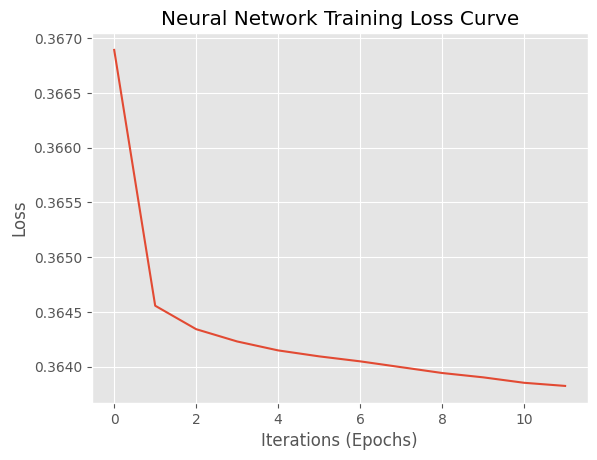


Neural Network artifacts exported successfully to /outputs.


In [28]:
# 1. Evaluate on the Validation Set
print("Evaluating Neural Network on the Validation Set...")
nn_evaluator = nn_model.evaluate(X_valid_prep, y_valid)

# 2. Display core metrics
display(nn_evaluator.summary())

# 3. Display the Confusion Matrix
print("\nConfusion Matrix:")
display(nn_evaluator.confusion())

# 4. Generate the Decile / Gains Table
nn_probs = nn_model.predict_proba(X_valid_prep)[:, 1]
nn_decile_table = nn_evaluator.decile_table(y_valid, nn_probs)

print("\nDecile Gains Table (Neural Network):")
display(nn_decile_table)

# 5. Optional: View the Loss Curve to see how the network converged
import matplotlib.pyplot as plt
plt.plot(nn_model.get_loss_curve())
plt.title("Neural Network Training Loss Curve")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss")
plt.show()

# 6. Save the Neural Network artifacts
nn_model.save("outputs/neural_network_benchmark.pkl")
nn_model.export_metadata("outputs/neural_network_metadata.json")
print("\nNeural Network artifacts exported successfully to /outputs.")

# 10. Model Comparison & Final Selection
With all four models trained and evaluated on the Validation Set, we can now compare their performance side-by-side.

In credit risk, we primarily focus on:

Gini / KS Statistic: Measures the model's ability to rank-order risk (higher is better).

ROC-AUC: Overall discriminatory power (higher is better).

Log Loss / Brier Score: Measures the calibration and accuracy of the predicted probabilities (lower is better).

In [29]:
# 1. Gather the metrics from all four evaluators
model_metrics = {
    "Logistic Regression": evaluator.metrics(),
    "XGBoost": xgb_evaluator.metrics(),
    "Random Forest": rf_evaluator.metrics(),
    "Neural Network": nn_evaluator.metrics()
}

# 2. Convert to a single DataFrame
comparison_df = pd.DataFrame(model_metrics)

# 3. Reorder the rows to put the most critical credit risk metrics at the top
priority_metrics = [
    "Gini", "KS", "ROC_AUC", "PR_AUC", 
    "LogLoss", "BrierScore", "Accuracy", 
    "F1", "Precision", "Recall", "Specificity"
]

# Ensure we only sort by metrics that exist, leaving counts (TP, TN, etc.) at the bottom
available_metrics = [m for m in priority_metrics if m in comparison_df.index]
other_metrics = [m for m in comparison_df.index if m not in available_metrics]
comparison_df = comparison_df.loc[available_metrics + other_metrics]

# 4. Apply Pandas Styling to highlight the best models
# - Green highlights the highest value for metrics where "higher is better"
# - Green highlights the lowest value for metrics where "lower is better" (Loss/Brier)
styled_comparison = (
    comparison_df.style
    .highlight_max(
        axis=1, 
        subset=pd.IndexSlice[["Gini", "KS", "ROC_AUC", "PR_AUC", "Accuracy", "F1", "Precision", "Recall", "Specificity"], :], 
        color='lightgreen'
    )
    .highlight_min(
        axis=1, 
        subset=pd.IndexSlice[["LogLoss", "BrierScore"], :], 
        color='lightgreen'
    )
    .format("{:.4f}")
)

print("Model Performance Comparison (Validation Set):")
display(styled_comparison)

# 5. Export the comparison table
comparison_df.to_csv("outputs/model_comparison_summary.csv")

Model Performance Comparison (Validation Set):


,Logistic Regression,XGBoost,Random Forest,Neural Network
Gini,0.3375,0.3542,0.3454,0.3470
KS,0.2454,0.2577,0.2509,0.2519
ROC_AUC,0.6687,0.6771,0.6727,0.6735
PR_AUC,0.2234,0.2311,0.2262,0.2278
LogLoss,0.6485,0.3634,0.6440,0.3648
BrierScore,0.2290,0.1078,0.2271,0.1081
Accuracy,0.6098,0.8701,0.6099,0.8701
F1,0.2984,0.0001,0.3008,0.0000
Precision,0.1947,0.3333,0.1960,0.0000
Recall,0.6390,0.0000,0.6461,0.0000
